# Physics Informed Neural Networks and Deep Operator Network for beginners

#### by [Francisco Periago](https://multisimo.com/fpe/)

### Experiment 1: PINN approximation of the solution to the Laplace-Poisson equation

\begin{equation}
\left\{\begin{array}{ll}
-\Delta u(x) = -2d, & x\in D:=(0,1)^d \\
u(x) = \sum_{k=1}^d x_k^2, & x\in \partial D 
\end{array}
\right.
\end{equation}

This problem has the exact solution

\begin{equation}
u_{\text{exact}}(x) = \sum_{k=1}^d x_k^2
\end{equation}

Our implementation uses [Lu, Lu and Meng, Xuhui and Mao, Zhiping and Karniadakis, George Em.: DeepXDE: A deep learning library for solving differential equations. SIAM Review. 63(1), 208-228 (2021)](https://github.com/lululxvi/deepxde)

In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
#from deepxde.backend import tf

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term



In [2]:
d = 2 # spatial dimension 

We define de Laplace-Poisson equation. Partial derivatives are computed by using [Automatic Differentation (AD)](https://www.jmlr.org/papers/volume18/17-468/17-468.pdf)

In [3]:
def pde(x, u): # Poisson's equation
    laplacian = sum(dde.grad.hessian(u, x, i=k, j=k) for k in range(d))
    return - laplacian + 2 * d
    


Let's define the geometry. In this case, it corresponds to the unit square $(0,1)^d$.

In [4]:
geom = dde.geometry.Hypercube([0] * d, [1] * d)


Next, we introduce the boundary conditions. For more details see [geometry_nd.py](https://github.com/lululxvi/deepxde/blob/master/deepxde/geometry/geometry_nd.py) 

In [5]:
# Boundary condition: u(x) = sum x_k^2
def boundary(x, on_boundary):
    return on_boundary

def boundary_value(x):
    return np.sum(np.square(x), axis=1, keepdims=True)

# Boundary condition
bc = dde.icbc.DirichletBC(geom, boundary_value, boundary)


Now, we introduce the dataset. This is composed of the geometry, the partial differential equation, boundary conditions, number of sampling quasi-random points in the interior of the domain, number of quasi-random points on the boundary, and number of quasi-random points (in the interior domain) that are used to check accuracy when solving the PDE.

By default, the [Hammersley distribution](https://en.wikipedia.org/wiki/Low-discrepancy_sequence) is used to select training points. More details may be found in  [pde.py](https://github.com/lululxvi/deepxde/blob/master/deepxde/data/pde.py)

In [6]:
data = dde.data.PDE(geom, pde, bc, num_domain=100, num_boundary=40, num_test=100) #, train_distribution="Hammersley"

c:\Users\Periagol\anaconda3\envs\deeponetcontrol\lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: __init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\Periagol\anaconda3\envs\deeponetcontrol\lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: __init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\Periagol\anaconda3\envs\deeponetcontrol\lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was

As an illustration we now plot the selected points for training and test.

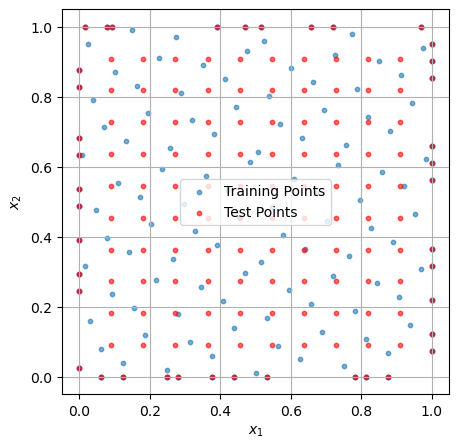

In [7]:
train_points = data.train_x  # Training points
test_points = data.test_x    # Test points ###

plt.figure(figsize=(5, 5))
plt.scatter(train_points[:, 0], train_points[:, 1], s=10, label='Training Points', alpha=0.6)
plt.scatter(test_points[:, 0], test_points[:, 1], s=10, label='Test Points', alpha=0.6, color='red')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.grid(True)
plt.show()

# if d=3 you may plot training and test points as follows:
#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')
#ax.scatter(train_points[:, 0], train_points[:, 1], train_points[:, 2], s=10, label='Training Points', alpha=0.6)
#ax.scatter(test_points[:, 0], test_points[:, 1], test_points[:, 2], s=10, label='Test Points', alpha=0.6, color='red')
#plt.legend()
#plt.grid(True)
#plt.show()


Next step is to select a network architecture to be used to approximate the solution of the PDE. In this case, we choose a feed-forward neural network where the input layer has dimension $d$, there are two hidden layers with $50$ neurons each one. The output is an scalar. As suggested in [Sifan Wang, Shyam Sankaran, Hanwen Wang, Paris Perdikaris: An Expert's Guide to Training Physics-informed Neural Networks](https://arxiv.org/abs/2308.08468) and the references therein, the hyperbolic tangent is chosen as activation function for all layers. The initialization of the parameters of the network is carried out by following a [Glorot uniform distribution.](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)

In [8]:
net = dde.nn.FNN([d] + [50] * 3 + [1], "tanh", "Glorot uniform")

Finally, we build the model, which is composed of data and net. 

The loss function is composed of the residuals for the initial, boundary conditions, and the PDE. Numerical integration is performed by computing the mean of the loss function evaluated at the training (and test) data.

The adaptive with moment algorithm (Adam) [Diederik P. Kingma, Jimmy Ba: Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980) is the optimizer of choice in deep learning, at least for the type of problems we are addressing here. The suggested learning rate is $lr=0.001$. Additionally, the weights for the PDE and boundary residuals may be selected. $1$ is the default value for all weights.

Compiling model...
Building feed-forward neural network...
'build' took 0.055801 s



c:\Users\Periagol\anaconda3\envs\deeponetcontrol\lib\site-packages\deepxde\nn\tensorflow_compat_v1\fnn.py:116: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  return tf.layers.dense(


'compile' took 0.474046 s

Training model...

Step      Train loss              Test loss               Test metric
0         [1.61e+01, 8.69e-01]    [1.60e+01, 8.69e-01]    []  
1000      [8.88e-04, 1.10e-04]    [8.47e-04, 1.10e-04]    []  
2000      [1.72e-04, 2.94e-05]    [1.68e-04, 2.94e-05]    []  
3000      [4.90e-05, 1.30e-05]    [4.75e-05, 1.30e-05]    []  
4000      [1.44e-05, 5.44e-06]    [1.39e-05, 5.44e-06]    []  
5000      [6.36e-06, 2.72e-06]    [6.20e-06, 2.72e-06]    []  
6000      [1.75e-04, 9.97e-04]    [1.47e-04, 9.97e-04]    []  
7000      [3.41e-06, 1.45e-06]    [3.27e-06, 1.45e-06]    []  
8000      [3.07e-06, 1.26e-06]    [2.87e-06, 1.26e-06]    []  
9000      [2.11e-05, 1.54e-05]    [2.20e-05, 1.54e-05]    []  
10000     [2.91e-06, 1.58e-06]    [2.65e-06, 1.58e-06]    []  

Best model at step 8000:
  train loss: 4.33e-06
  test loss: 4.14e-06
  test metric: []

'train' took 15.385234 s

Compiling model...
'compile' took 0.329314 s

Training model...

Step      

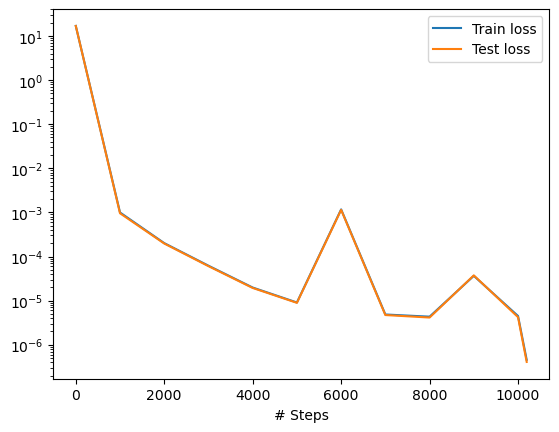

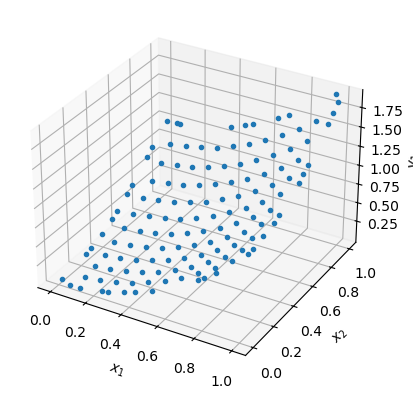

In [9]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001, loss_weights=[1.0, 1.0]) # The weights for the contribution of the PDE and boundary residual 
model.train(iterations=10000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Finally, we may compare the PINN and the exact solutions. 

In [10]:
# Predict
X = geom.uniform_points(1000)
y_pred = model.predict(X)
print(X.shape)

# Exact solution
y_exact = np.sum(X ** 2, axis=1, keepdims=True)

# Comparison
error = np.linalg.norm(y_pred - y_exact, 2) / np.linalg.norm(y_exact, 2)
print("Relative L2 error:", error)

(1024, 2)
Relative L2 error: 0.00019177732


And, graphycally for the case $d=2$

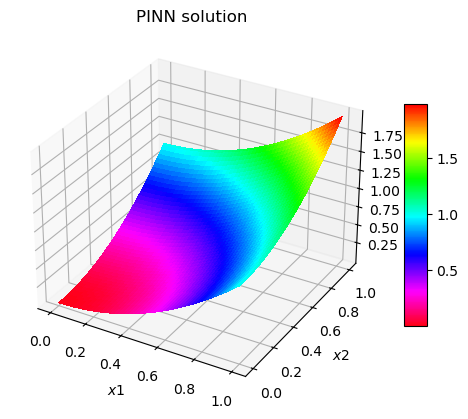

In [11]:
x_1 = np.linspace(0, 1, 100)
x_2 = np.linspace(0, 1, 100)
   
x_1_repeated = np.repeat(x_1,  x_2.shape[0])  # repeat each value of X the number of elements of t    
x_2_tiled = np.tile(x_2, x_1.shape[0]) # repeat the whole vector t, the number of elements of X    
xx = np.vstack((x_1_repeated, x_2_tiled)).T # stack them vertically and take the transpose
        
sol_predict = model.predict(xx).T # predicted solution
sol_predict_M = sol_predict.reshape((100,100)).T # predicted state in matrix form

x1, x2 = np.meshgrid(
    np.linspace(0, 1, 100),
    np.linspace(0, 1, 100)
    )

fig = plt.figure() # plot of predicted solution
ax = plt.axes(projection="3d")
surf = ax.plot_surface(x1, x2, sol_predict_M, 
                        cmap='hsv_r', linewidth=0, antialiased=False)

ax.set_title('PINN solution ')
ax.set_xlabel('$x1$')
ax.set_ylabel('$x2$')
fig.colorbar(surf, shrink=0.6, aspect=10)    
plt.show()

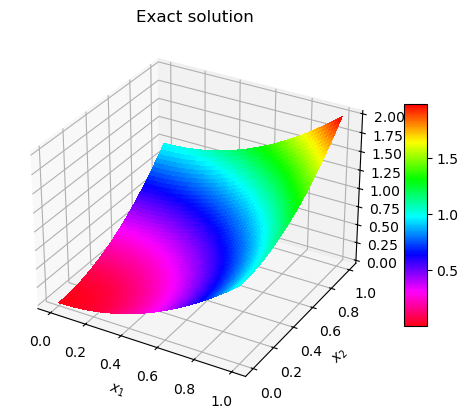

In [12]:

x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1, x2)

exact = X1**2 + X2**2 # exact solution

# Plot
fig = plt.figure() # plot of exact solution
ax = plt.axes(projection="3d")
surf_2 = ax.plot_surface(X1, X2, exact, cmap='hsv_r', linewidth=0, antialiased=False)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$y$')
ax.set_title('Exact solution')
fig.colorbar(surf_2, shrink=0.6, aspect=10) 
plt.show()